In [2]:
print("hello world")

hello world


In [3]:
#import dataset
import pandas as pd
predictive_maintenance=pd.read_csv(r"D:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\predictive_maintenance.csv")
print(predictive_maintenance.head(5))

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target  
0                    1551         42.8                0       0  
1                    1408         46.3                3       0  
2                    1498         49.4                5       0  
3                    1433         39.5                7       0  
4                    1408         40.0                9       0  


In [4]:
#Discribe 
predictive_maintenance.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
#Check Information of dataset
predictive_maintenance.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 771.6 KB


In [6]:
#Check Null values in dataset
predictive_maintenance.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

In [7]:
#Drop Duplicate values
predictive_maintenance.drop_duplicates(inplace=True)

In [8]:
#check skewness of dataset
predictive_maintenance_numeric=predictive_maintenance.skew(numeric_only=True)
predictive_maintenance_numeric

UDI                        0.000000
Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
Target                     5.151852
dtype: float64

In [9]:
#Remove skewness by using IQR mothed
#To find IQR
for column in predictive_maintenance.select_dtypes(include=['float64', 'int64']).columns:
    q1 = predictive_maintenance[column].quantile(0.25)
    q3 = predictive_maintenance[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    predictive_maintenance = predictive_maintenance[(predictive_maintenance[column] >= lower_bound) & (predictive_maintenance[column] <= upper_bound)]  


In [10]:
#agian Check Skewness of dataset    
predictive_maintenance.skew(numeric_only=True)

UDI                       -0.009216
Air temperature [K]        0.142633
Process temperature [K]    0.037414
Rotational speed [rpm]     0.580908
Torque [Nm]                0.151852
Tool wear [min]            0.030817
Target                     0.000000
dtype: float64

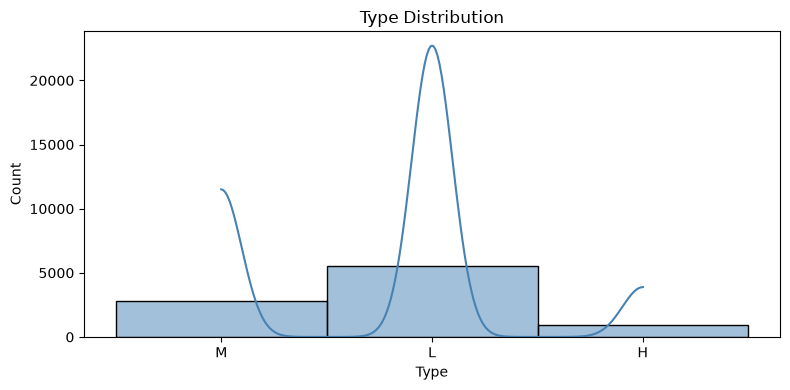

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
if 'Type' in predictive_maintenance.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(predictive_maintenance["Type"].dropna(), bins=30, kde=True, color="steelblue")
    plt.title("Type Distribution")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


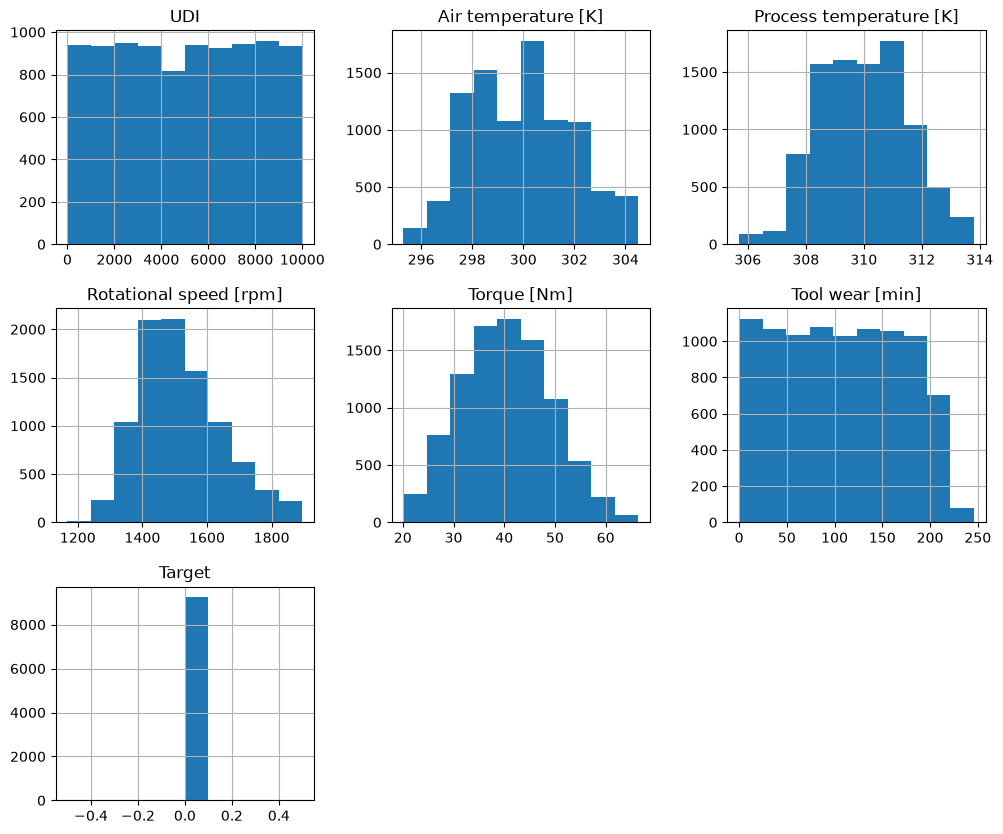

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
predictive_maintenance.hist(figsize=(12,10))
plt.show()

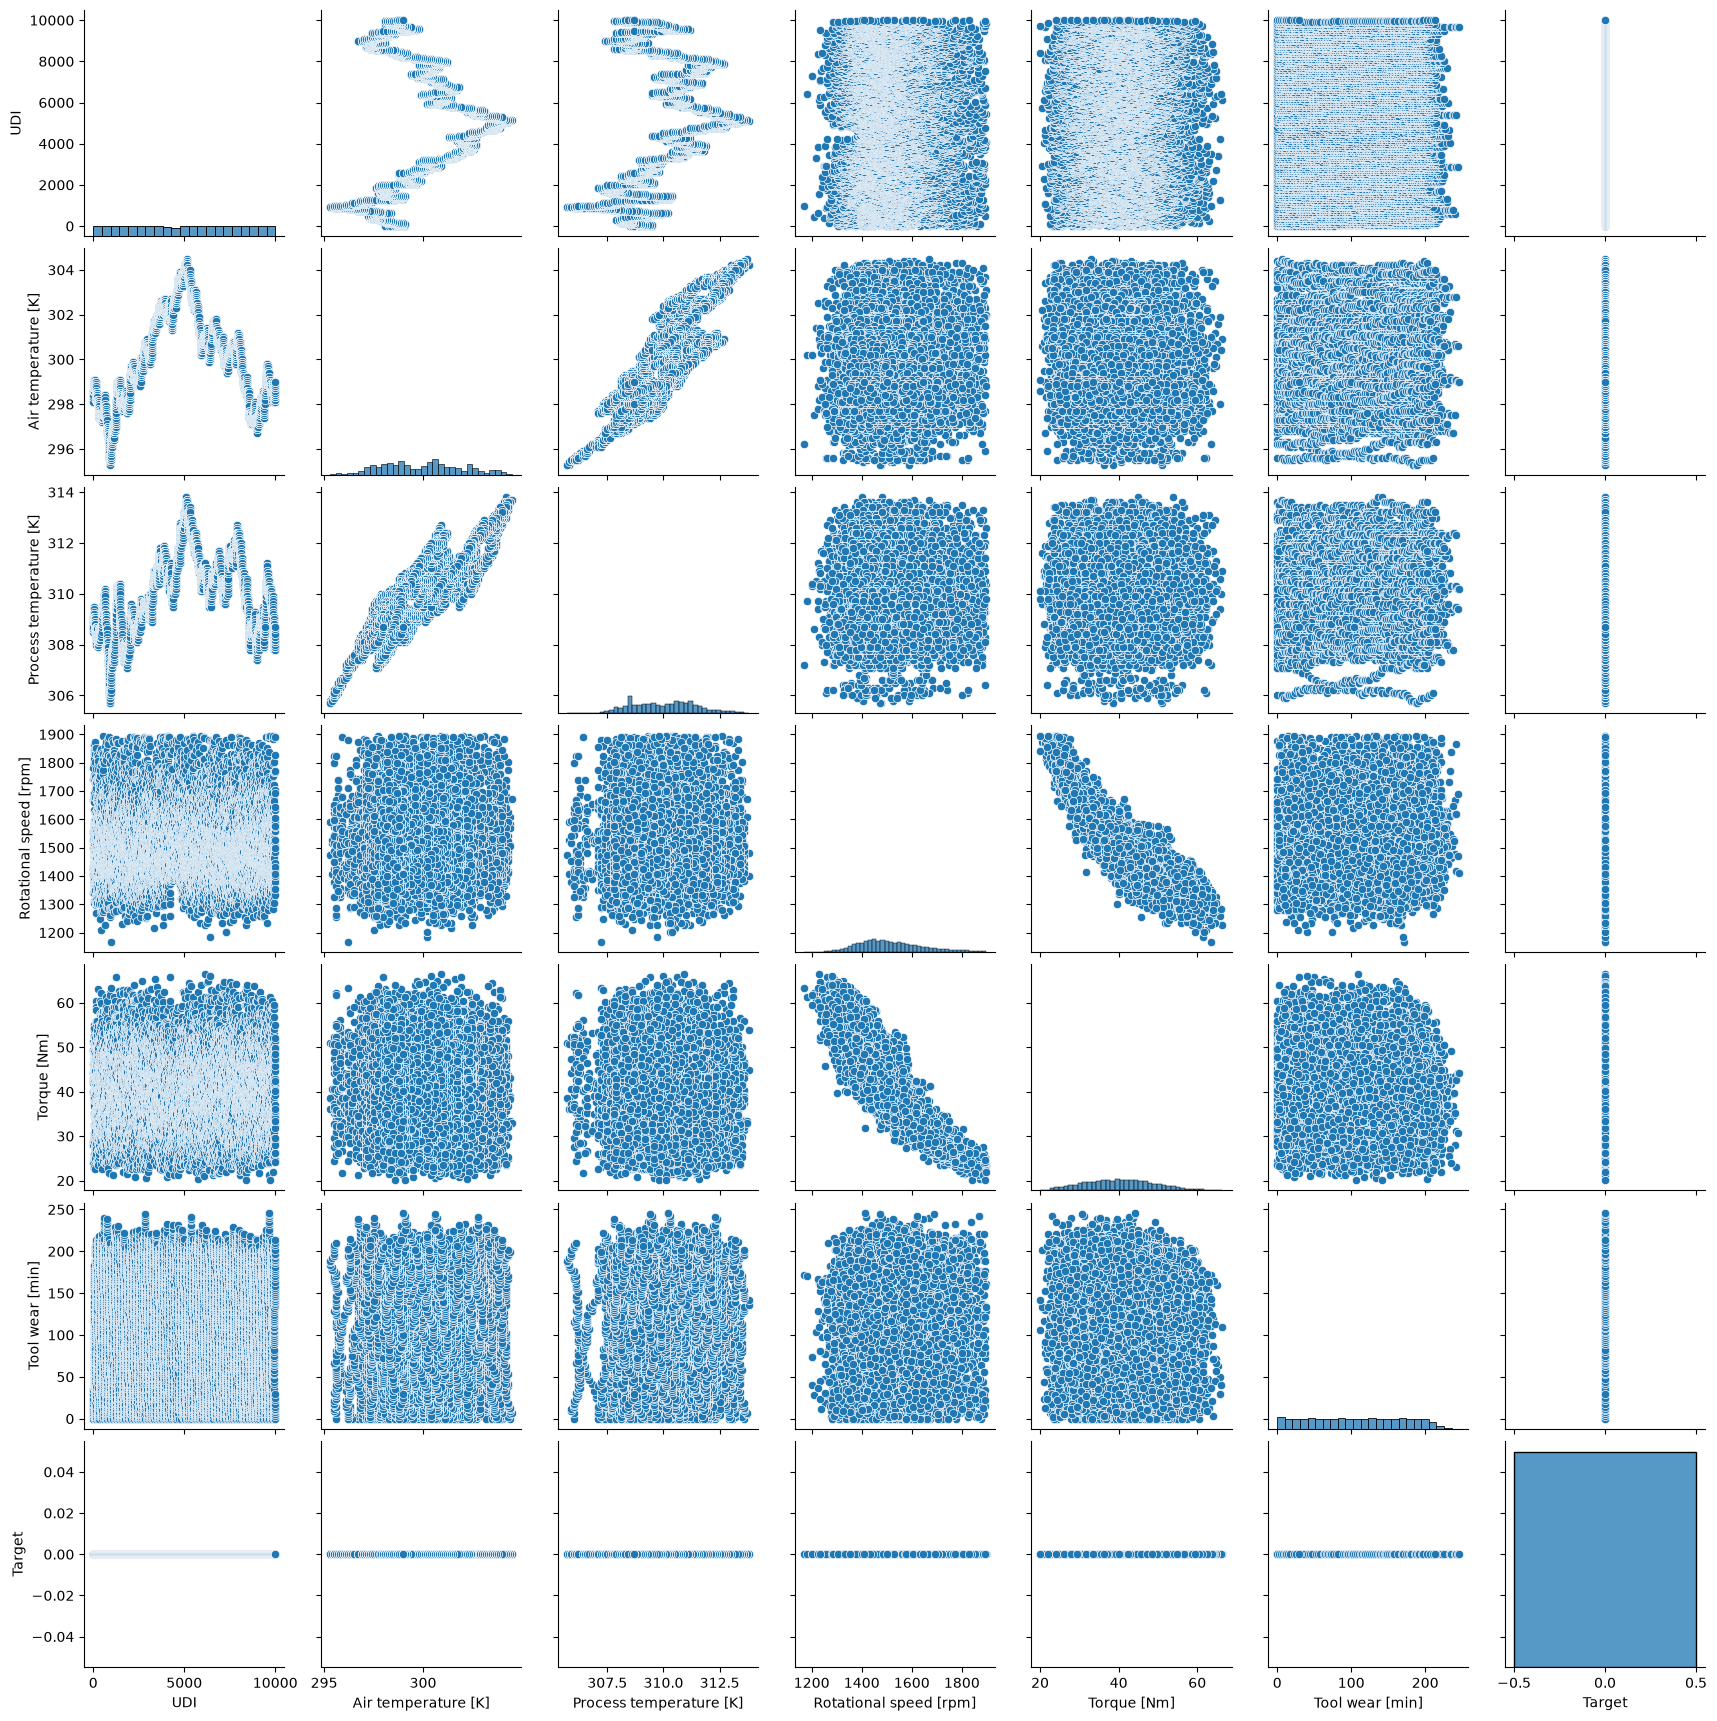

In [13]:
sns.pairplot(predictive_maintenance)

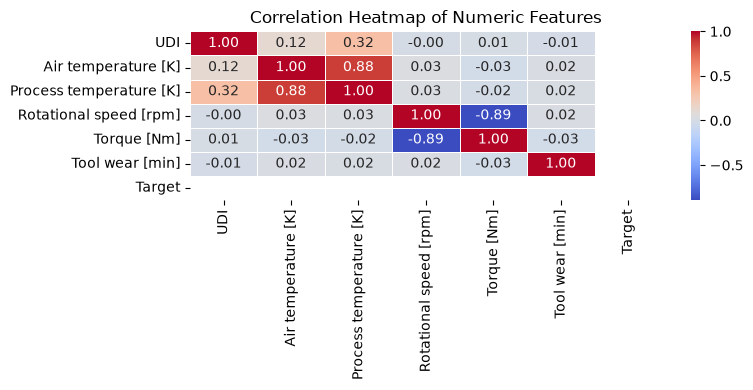

In [14]:
corr= predictive_maintenance.corr(numeric_only=True)
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

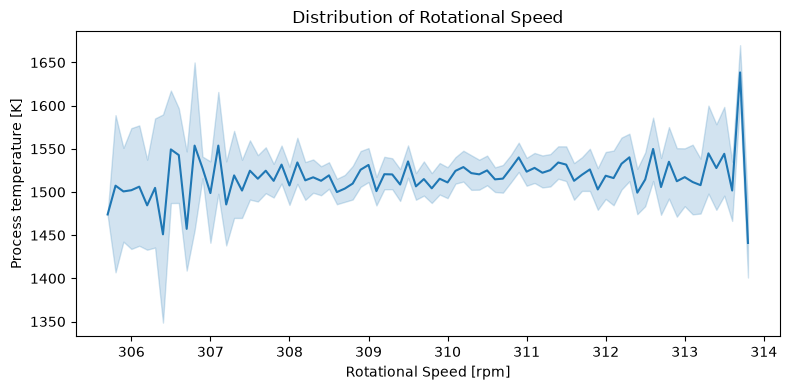

In [15]:
plt.figure(figsize=(8,4))
sns.lineplot(data=predictive_maintenance,x='Process temperature [K]',y='Rotational speed [rpm]')
plt.title("Distribution of Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Process temperature [K]")
plt.tight_layout()

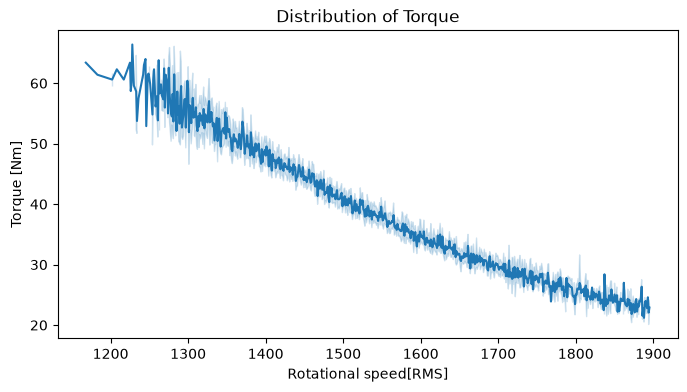

In [16]:
plt.figure(figsize=(8,4))
sns.lineplot(data=predictive_maintenance,x='Rotational speed [rpm]',y='Torque [Nm]')
plt.title("Distribution of Torque")
plt.xlabel("Rotational speed[RMS]")
plt.ylabel("Torque [Nm]")
plt.show()

In [17]:
#here skewness is not found in dataset so we can move to next step of data scaling and encoding of categorical data.
#copy dataset for scaling and encoding 
predictive_maintenance_copy=predictive_maintenance.copy()
predictive_maintenance_copy.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [18]:
#convert categorical data into numerical data using label encoding
import numpy as np
import sklearn.preprocessing as preprocessing
#predictive_maintenance_copy.drop(columns=['Type','UDI', 'Product ID'], inplace=True)
predictive_maintenance_copy.head(5)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [19]:
# Now we can move to next step to model building and training.frist we will split the dataset into train and test dataset.
# and then we will apply scaling on dataset(to avoid data lekdge) and then we will train the model using different algorithms 
# and check the accuracy of each model and then we will select the best model and then we will save the model for deployment.

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Separate Features and Target
X = predictive_maintenance_copy.drop(columns=['Target', 'UDI', 'Product ID'])
Y = predictive_maintenance_copy['Target']

# 2. Convert 'Type' to numeric features via One-Hot Encoding
# (dtype=int forces True/False to convert to clean 1s and 0s)
encode = pd.get_dummies(X, columns=['Type'], drop_first=True, dtype=int)
X = pd.get_dummies(X, columns=['Type'], drop_first=True, dtype=int)

# 3. Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# 4. Reset indices completely to eliminate alignment bugs
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

# 5. Scale the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Apply SMOTE with clean conditional logic
smote = SMOTE(random_state=42)

if len(np.unique(Y_train)) > 1:
    X_train_resampled, Y_train_resampled = smote.fit_resample(X_train_scaled, Y_train)
else:
    # Fallback if there is only 1 class in the training split
    X_train_resampled, Y_train_resampled = X_train_scaled, Y_train

print("Data processing pipeline complete!")
print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")


Data processing pipeline complete!
Original training shape: (7417, 7)
Resampled training shape: (7417, 7)


In [21]:
# model importing
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [22]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Now model building is performing
Results = {}

# 1. Initialize Model
# (Removed class_weight='balanced' since SMOTE already perfectly balanced the training data)
rf_model = RandomForestClassifier(random_state=42)

# 2. Fit the model on the RESAMPLED training data
rf_model.fit(X_train_resampled, Y_train_resampled)

# 3. Predict on the scaled features
Y_train_pred = rf_model.predict(X_train_scaled)  # Predicts on original training distribution
Y_test_pred = rf_model.predict(X_test_scaled)    # Predicts on real-world test data

# 4. Save Results with Correct Variable Names
Results['RandomForestClassifier'] = {
    # Train accuracy checks how well it fits the SMOTE-balanced training set
    'Train_Accuracy': accuracy_score(Y_train_resampled, rf_model.predict(X_train_resampled)),
    
    # Test metrics MUST use the original, untouched Y_test labels
    'Test_Accuracy': accuracy_score(Y_test, Y_test_pred),
    'Classification_Report': classification_report(Y_test, Y_test_pred),
    'f_score': classification_report(Y_test, Y_test_pred, output_dict=True)['macro avg']['f1-score'],
    'Confusion_Matrix': confusion_matrix(Y_test, Y_test_pred)
}

# Print the dictionary to see your new realistic scores!
import pprint
pprint.pprint(Results['RandomForestClassifier'])



{'Classification_Report': '              precision    recall  f1-score   '
                          'support\n'
                          '\n'
                          '           0       1.00      1.00      1.00      '
                          '1855\n'
                          '\n'
                          '    accuracy                           1.00      '
                          '1855\n'
                          '   macro avg       1.00      1.00      1.00      '
                          '1855\n'
                          'weighted avg       1.00      1.00      1.00      '
                          '1855\n',
 'Confusion_Matrix': array([[1855]]),
 'Test_Accuracy': 1.0,
 'Train_Accuracy': 1.0,
 'f_score': 1.0}


d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [23]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pprint



# 1. Initialize the Decision Tree Model
# (No class_weight='balanced' needed since SMOTE already balanced the training data)
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Fit the model on the RESAMPLED training data
dt_model.fit(X_train_resampled, Y_train_resampled)

# 3. Predict on the scaled features
Y_train_pred = dt_model.predict(X_train_scaled)  # Predicts on original training distribution
Y_test_pred = dt_model.predict(X_test_scaled)    # Predicts on real-world test data

# 4. Save Results under the 'DecisionTreeClassifier' key
Results['DecisionTreeClassifier'] = {
    # Train accuracy checks how well it fits the SMOTE-balanced training set
    'Train_Accuracy': accuracy_score(Y_train_resampled, dt_model.predict(X_train_resampled)),
    
    # Test metrics use the original, untouched Y_test labels
    'Test_Accuracy': accuracy_score(Y_test, Y_test_pred),
    'Classification_Report': classification_report(Y_test, Y_test_pred),
    'f_score': classification_report(Y_test, Y_test_pred, output_dict=True)['macro avg']['f1-score'],
    'Confusion_Matrix': confusion_matrix(Y_test, Y_test_pred)
}

# Print the dictionary to see your Decision Tree performance!
print("--- Decision Tree Classifier Results ---")
pprint.pprint(Results['DecisionTreeClassifier'])


--- Decision Tree Classifier Results ---
{'Classification_Report': '              precision    recall  f1-score   '
                          'support\n'
                          '\n'
                          '           0       1.00      1.00      1.00      '
                          '1855\n'
                          '\n'
                          '    accuracy                           1.00      '
                          '1855\n'
                          '   macro avg       1.00      1.00      1.00      '
                          '1855\n'
                          'weighted avg       1.00      1.00      1.00      '
                          '1855\n',
 'Confusion_Matrix': array([[1855]]),
 'Test_Accuracy': 1.0,
 'Train_Accuracy': 1.0,
 'f_score': 1.0}


d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [24]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pprint
from sklearn.dummy import DummyClassifier


# 1. Initialize the Logistic Regression Model
# max_iter=1000 ensures the solver has enough iterations to find the mathematical minimum
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# 2. Fit the model on the RESAMPLED training data
if len(np.unique(Y_train_resampled)) > 1:
    lr_model.fit(X_train_resampled, Y_train_resampled)
else:
    const_class = int(pd.Series(Y_train_resampled).iloc[0])

    # 1. Initialize the Logistic Regression Model
    lr_model = LogisticRegression(random_state=42, max_iter=1000)

    # 2. Fit the model on the RESAMPLED training data
    if len(np.unique(Y_train_resampled)) > 1:
        lr_model.fit(X_train_resampled, Y_train_resampled)
    else:
        const_class = int(pd.Series(Y_train_resampled).iloc[0])
        lr_model = DummyClassifier(strategy="constant", constant=const_class)
        lr_model.fit(X_train_resampled, Y_train_resampled)
        print(f"Only one class ({const_class}) in training data — using DummyClassifier.")

    # 3. Predict on the scaled features
    Y_train_pred = lr_model.predict(X_train_scaled)  # Predicts on original training distribution
    Y_test_pred = lr_model.predict(X_test_scaled)    # Predicts on real-world test data

    # 4. Save Results under the 'LogisticRegression' key
    Results['LogisticRegression'] = {
        'Train_Accuracy': accuracy_score(Y_train_resampled, lr_model.predict(X_train_resampled)),
        'Test_Accuracy': accuracy_score(Y_test, Y_test_pred),
        'Classification_Report': classification_report(Y_test, Y_test_pred),
        'f_score': classification_report(Y_test, Y_test_pred, output_dict=True)['macro avg']['f1-score'],
        'Confusion_Matrix': confusion_matrix(Y_test, Y_test_pred)
    }

    print("--- Logistic Regression Results ---")
    pprint.pprint(Results['LogisticRegression'])
    lr_model.fit(X_train_resampled, Y_train_resampled)
    print(f"Only one class ({const_class}) in training data — using DummyClassifier.")



Only one class (0) in training data — using DummyClassifier.
--- Logistic Regression Results ---
{'Classification_Report': '              precision    recall  f1-score   '
                          'support\n'
                          '\n'
                          '           0       1.00      1.00      1.00      '
                          '1855\n'
                          '\n'
                          '    accuracy                           1.00      '
                          '1855\n'
                          '   macro avg       1.00      1.00      1.00      '
                          '1855\n'
                          'weighted avg       1.00      1.00      1.00      '
                          '1855\n',
 'Confusion_Matrix': array([[1855]]),
 'Test_Accuracy': 1.0,
 'Train_Accuracy': 1.0,
 'f_score': 1.0}
Only one class (0) in training data — using DummyClassifier.


d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [25]:
%pip install xgboost
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pprint

# 1. Initialize the XGBoost Model
# eval_metric='logloss' suppresses the default warning message in newer versions
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Fit the model on the RESAMPLED training data
xgb_model.fit(X_train_resampled, Y_train_resampled)

# 3. Predict on the scaled features
Y_train_pred = xgb_model.predict(X_train_scaled)  # Predicts on original training distribution
Y_test_pred = xgb_model.predict(X_test_scaled)    # Predicts on real-world test data

# 4. Save Results under the 'XGBClassifier' key
Results['XGBClassifier'] = {
    # Train accuracy checks how well it fits the SMOTE-balanced training set
    'Train_Accuracy': accuracy_score(Y_train_resampled, xgb_model.predict(X_train_resampled)),
    
    # Test metrics use the original, untouched Y_test labels
    'Test_Accuracy': accuracy_score(Y_test, Y_test_pred),
    'Classification_Report': classification_report(Y_test, Y_test_pred),
    'f_score': classification_report(Y_test, Y_test_pred, output_dict=True)['macro avg']['f1-score'],
    'Confusion_Matrix': confusion_matrix(Y_test, Y_test_pred)
}

# Print the dictionary to see your XGBoost performance!
print("--- XGBoost Classifier Results ---")
pprint.pprint(Results['XGBClassifier'])


Note: you may need to restart the kernel to use updated packages.
--- XGBoost Classifier Results ---
{'Classification_Report': '              precision    recall  f1-score   '
                          'support\n'
                          '\n'
                          '           0       1.00      1.00      1.00      '
                          '1855\n'
                          '\n'
                          '    accuracy                           1.00      '
                          '1855\n'
                          '   macro avg       1.00      1.00      1.00      '
                          '1855\n'
                          'weighted avg       1.00      1.00      1.00      '
                          '1855\n',
 'Confusion_Matrix': array([[1855]]),
 'Test_Accuracy': 1.0,
 'Train_Accuracy': 1.0,
 'f_score': 1.0}


d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [26]:
#XGB with hyperparameter tuneing

In [27]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_resampled, Y_train_resampled)

best_xgb = xgb_grid.best_estimator_
best_params = xgb_grid.best_params_

print("Best XGBoost hyperparameters:")
print(best_params)

Y_test_pred = best_xgb.predict(X_test_scaled)
Y_train_pred = best_xgb.predict(X_train_scaled)

Results['XGB_Tuned'] = {
    'Train_Accuracy': accuracy_score(Y_train_resampled, best_xgb.predict(X_train_resampled)),
    'Test_Accuracy': accuracy_score(Y_test, Y_test_pred),
    'Classification_Report': classification_report(Y_test, Y_test_pred),
    'f_score': classification_report(Y_test, Y_test_pred, output_dict=True)['macro avg']['f1-score'],
    'Confusion_Matrix': confusion_matrix(Y_test, Y_test_pred),
    'Best_Params': best_params
}

print("--- Tuned XGBoost Classifier Results ---")
print("Train Accuracy:", Results['XGB_Tuned']['Train_Accuracy'])
print("Test Accuracy:", Results['XGB_Tuned']['Test_Accuracy'])
print("Classification Report:")
print(Results['XGB_Tuned']['Classification_Report'])
print("Confusion Matrix:")
print(Results['XGB_Tuned']['Confusion_Matrix'])

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best XGBoost hyperparameters:
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
--- Tuned XGBoost Classifier Results ---
Train Accuracy: 1.0
Test Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1855

    accuracy                           1.00      1855
   macro avg       1.00      1.00      1.00      1855
weighted avg       1.00      1.00      1.00      1855

Confusion Matrix:
[[1855]]


d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [29]:
import pandas as pd
results_df = pd.DataFrame(Results).T
results_df

,Train_Accuracy,Test_Accuracy,Classification_Report,f_score,Confusion_Matrix,Best_Params
RandomForestClassifier,1.0,1.0,precision recall f1-score ...,1.0,[[1855]],NaN
DecisionTreeClassifier,1.0,1.0,precision recall f1-score ...,1.0,[[1855]],NaN
LogisticRegression,1.0,1.0,precision recall f1-score ...,1.0,[[1855]],NaN
XGBClassifier,1.0,1.0,precision recall f1-score ...,1.0,[[1855]],NaN
XGB_Tuned,1.0,1.0,precision recall f1-score ...,1.0,[[1855]],"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."


In [30]:
gap = results_df['Train_Accuracy'] - results_df['Test_Accuracy']

results_df['Overfitting Status'] = gap.apply(
    lambda x: 'Overfitting' if x > 0.03 else ('Underfitting' if x < -0.01 else 'Good Fit')
)

# 5. Display (excluding the raw report text for a cleaner look if desired)
results_df[['Train_Accuracy', 'Test_Accuracy', 'f_score', 'Overfitting Status']]

,Train_Accuracy,Test_Accuracy,f_score,Overfitting Status
RandomForestClassifier,1.0,1.0,1.0,Good Fit
DecisionTreeClassifier,1.0,1.0,1.0,Good Fit
LogisticRegression,1.0,1.0,1.0,Good Fit
XGBClassifier,1.0,1.0,1.0,Good Fit
XGB_Tuned,1.0,1.0,1.0,Good Fit


In [31]:
import joblib
joblib.dump(xgb_model,'predictive_maintenance.pkl')
joblib.dump(encode,'encode.pkl')
print("All modeling components saved successfully!")

All modeling components saved successfully!


In [32]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [33]:
import joblib
import pandas as pd
import streamlit as st

# Paths
MODEL_PATH = "predictive_maintenance.pkl"
DATA_PATH = r"D:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\predictive_maintenance.csv"

# Load saved model artifact
@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

model = load_model()

# Exact training feature structure columns expected by the model
feature_cols = [
    'Air temperature [K]', 
    'Process temperature [K]',
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]',
    'Type_L', 
    'Type_M'
]

# Streamlit UI
st.title("Predictive Maintenance Dashboard")
st.write("Enter the machine parameters below to predict failure.")

# Create input layout
inputs = {}
cols = st.columns(2)  # Splits inputs into two columns for better UI

# Numerical features that require user input boxes
numerical_cols = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

# FIX: Safely compute numeric medians by filtering out text columns first
try:
    df = pd.read_csv(DATA_PATH)
    # select_dtypes(include='number') drops text columns like 'Product ID' to prevent the error
    numeric_df = df.select_dtypes(include='number') 
    default_values = {col: float(numeric_df[col].median()) for col in numerical_cols}
except Exception:
    # Safe backup values if the CSV path is missing or fails to load
    default_values = {
        'Air temperature [K]': 300.0,
        'Process temperature [K]': 310.0,
        'Rotational speed [rpm]': 1500.0,
        'Torque [Nm]': 40.0,
        'Tool wear [min]': 100.0
    }

# Build numeric input widgets
for i, col in enumerate(numerical_cols):
    with cols[i % 2]:
        inputs[col] = st.number_input(
            label=col,
            value=default_values[col],
            step=0.1 if 'temperature' in col else 1.0
        )

# Handle Categorical Machine Type (Map dropdown options directly to Type_L and Type_M flags)
with cols[len(numerical_cols) % 2]:
    machine_type = st.selectbox("Product Type", options=["Low (L)", "Medium (M)", "High (H)"])

# Assign values based on dropdown selection
if machine_type == "Low (L)":
    inputs['Type_L'] = 1
    inputs['Type_M'] = 0
elif machine_type == "Medium (M)":
    inputs['Type_L'] = 0
    inputs['Type_M'] = 1
else:  # High (H) acts as the baseline reference category
    inputs['Type_L'] = 0
    inputs['Type_M'] = 0

# Prediction logic
if st.button("Predict Machine Status", type="primary"):
    # Enforce exact column arrangement your model expects
    input_df = pd.DataFrame([inputs], columns=feature_cols)
    
    # Generate prediction array
    prediction = model.predict(input_df)
    
    # Display result status banners
    if prediction[0] == 0:
        st.success("Machine Status: **No Failure (Normal Operation)**")
    else:
        st.error("Machine Status: **Failure Detected! Maintenance Required**")


2026-07-14 17:13:36.717 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 17:13:36.723 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 17:13:37.436 
  command:

    streamlit run d:\NITIN\ML_Deployment\CAPSTONE PROJECT 1\CAPSTONE PROJECT 1\Predictive Maintenance\myenv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-14 17:13:37.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 17:13:37.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 17:13:37.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 17:13:37.436 Thread 'MainThread'